# How to generate a privacy report?

### Check that the synthetic data protect the privacy of the real data

Assume that the synthetic data is already generated \
Based on the Wisconsin Breast Cancer Dataset

In [1]:
# Standard library
import sys
import tempfile
from pathlib import Path

sys.path.append("..")

# 3rd party packages
import pandas as pd

# Local packages
import config
import utils.draw
from metrics.privacy.report import PrivacyReport

## Load the real and synthetic WBCD datasets

In [2]:
df_real = {}
df_real["train"] = pd.read_csv(
    "../data/" + config.WBCD_DATASET_TRAIN_FILEPATH.stem + ".csv"
)
df_real["test"] = pd.read_csv(
    "../data/" + config.WBCD_DATASET_TEST_FILEPATH.stem + ".csv"
)
df_real["train"].shape

(359, 10)

### Choose the synthetic dataset

In [3]:
df_synth = {}  # generated by Synthpop ordered here
df_synth["train"] = pd.read_csv("../results/data/2023-07-31_Synthpop_359samples.csv")
df_synth["test"] = pd.read_csv("../results/data/2023-07-31_Synthpop_90samples.csv")
df_synth["test"].shape

(90, 10)

## Configure the metadata dictionary

### The continuous and categorical variables need to be specified, as well as the variable to predict for the future learning task

In [4]:
metadata = {
    "continuous": [
        "Clump_Thickness",
        "Uniformity_of_Cell_Size",
        "Uniformity_of_Cell_Shape",
        "Marginal_Adhesion",
        "Single_Epithelial_Cell_Size",
        "Bland_Chromatin",
        "Normal_Nucleoli",
        "Mitoses",
        "Bare_Nuclei",
    ],
    "categorical": ["Class"],
    "variable_to_predict": "Class",
}

## Generate the privacy report

In [5]:
report = PrivacyReport(
    dataset_name="Wisconsin Breast Cancer Dataset",
    df_real=df_real,
    df_synthetic=df_synth,
    metadata=metadata,
    figsize=(8, 6),  # will be automatically adjusted for larger or longer figures
    random_state=0,  # for reproducibility purposes
    report_filepath=None,  # load a computed report if available
    metrics=None,  # list of the metrics to compute. If not specified, all the metrics are computed.
    sampling_frac=0.5,  # the fraction of data to sample from real and synthetic datasets for better computing performance
)

In [6]:
report.compute()

## Get the summary report as a pandas dataframe

In [7]:
report.specification()

----- Wisconsin Breast Cancer Dataset -----
Contains:
    - 359 instances in the train set,
    - 90 instances in the test set,
    - 10 variables, 9 continuous and 1 categorical.


In [8]:
df_summary = report.summary()

In [9]:
by = ["name", "objective", "min", "max"]
df_summary.groupby(by).apply(lambda x: x.drop(by, axis=1).reset_index(drop=True))

alias                           submetric     value
name objective min max                                                      
DCR  max       0   1.0 0   dcr    nndr_5th_percent_synthreal_train  0.460000
                       1   dcr  nndr_5th_percent_synthreal_control  0.500000
                   inf 0   dcr     dcr_5th_percent_synthreal_train  0.011111
                       1   dcr   dcr_5th_percent_synthreal_control  0.011111
     min       0   1.0 0   dcr         ratio_match_synthreal_train  0.000000
                       1   dcr       ratio_match_synthreal_control  0.022222

## Display the detailed report

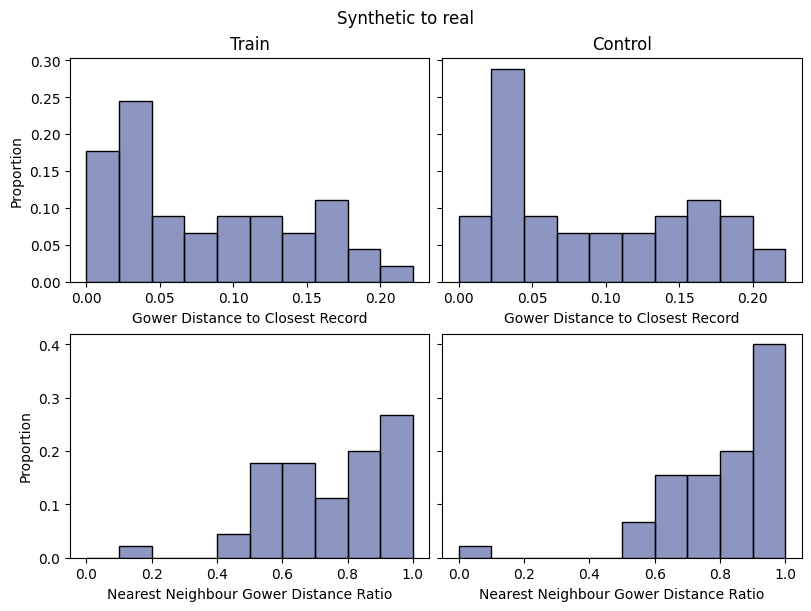

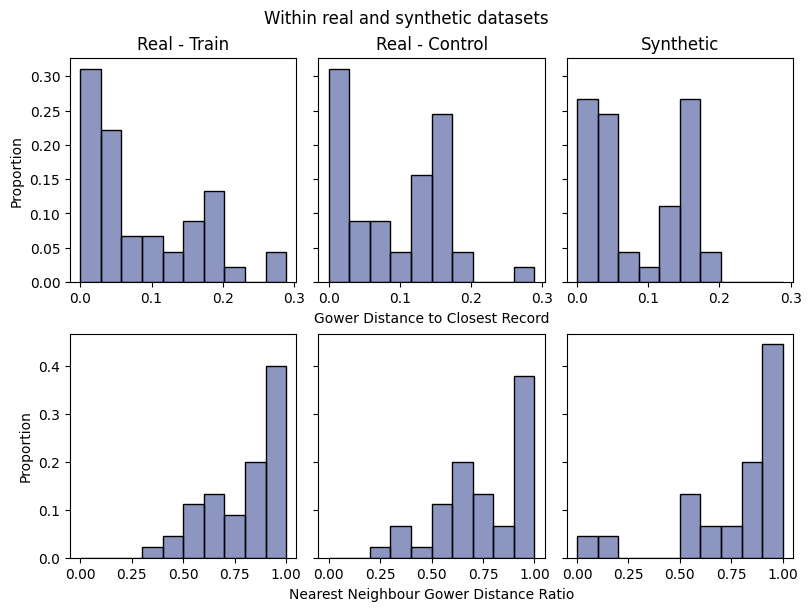

In [10]:
report.detailed(show=True, save_folder=None, figure_format="png")

## Save and load the report

In [11]:
with tempfile.TemporaryDirectory() as temp_dir:
    report.save(savepath=temp_dir, filename="privacy_report")  # save
    new_report = PrivacyReport(
        report_filepath=Path(temp_dir) / "privacy_report.pkl"
    )  # load

## For more functionalities, see the utility_report notebook